In [2]:
# ============================================================
# TASK 1: Iris Flower Classification — CodeAlpha Internship
# ============================================================
# Description:
#   Classify Iris flower species (setosa, versicolor, virginica)
#   using sepal/petal measurements. I train multiple models,
#   evaluate their accuracy, and visualize the results.
# Libraries: scikit-learn, pandas, matplotlib, seaborn
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


In [3]:
# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
df=pd.read_csv('Iris.csv')

In [4]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("=" * 55)
print("         IRIS FLOWER CLASSIFICATION")
print("=" * 55)
print(f"\n Dataset Shape: {df.shape}")
print(f"\n First 5 Rows:\n{df.head()}")
print(f"\n Statistical Summary:\n{df.describe().round(2)}")
print(f"\n Missing Values: {df.isnull().sum().sum()}")

         IRIS FLOWER CLASSIFICATION

 Dataset Shape: (150, 5)

 First 5 Rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

 Statistical Summary:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             150.00            150.00             150.00   
mean                5.84              3.06               3.76   
std                 0.83              0.44               1.77   
min                 4.30              2.00               1.00   
25%                 5.10   

In [5]:
# 3. PREPARE DATA
import pandas as pd
df = pd.DataFrame(iris.data, columns=iris.feature_names)
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\n Train/Test Split: {X_train.shape[0]} train | {X_test.shape[0]} test")


 Train/Test Split: 120 train | 30 test


In [6]:
# 4. TRAIN & COMPARE MULTIPLE MODELS

models = {
    "Logistic Regression":  LogisticRegression(max_iter=200, random_state=42),
    "Decision Tree":        DecisionTreeClassifier(random_state=42),
    "Random Forest":        RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (RBF Kernel)":     SVC(kernel='rbf', C=1.0, random_state=42),
    "K-Nearest Neighbors":  KNeighborsClassifier(n_neighbors=5),
}

results = {}


for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    acc = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_train_sc, y_train, cv=5)
    results[name] = {
        "test_accuracy": acc,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std(),
    }
    print(f"\n {name}")
    print(f"   Test Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
    print(f"   CV Mean ± Std  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")



 Logistic Regression
   Test Accuracy  : 0.9333 (93.33%)
   CV Mean ± Std  : 0.9583 ± 0.0264

 Decision Tree
   Test Accuracy  : 0.9333 (93.33%)
   CV Mean ± Std  : 0.9417 ± 0.0204

 Random Forest
   Test Accuracy  : 0.9000 (90.00%)
   CV Mean ± Std  : 0.9500 ± 0.0167

 SVM (RBF Kernel)
   Test Accuracy  : 0.9667 (96.67%)
   CV Mean ± Std  : 0.9667 ± 0.0312

 K-Nearest Neighbors
   Test Accuracy  : 0.9333 (93.33%)
   CV Mean ± Std  : 0.9667 ± 0.0312



BEST MODEL: SVM (RBF Kernel)

Test Accuracy: 96.67%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



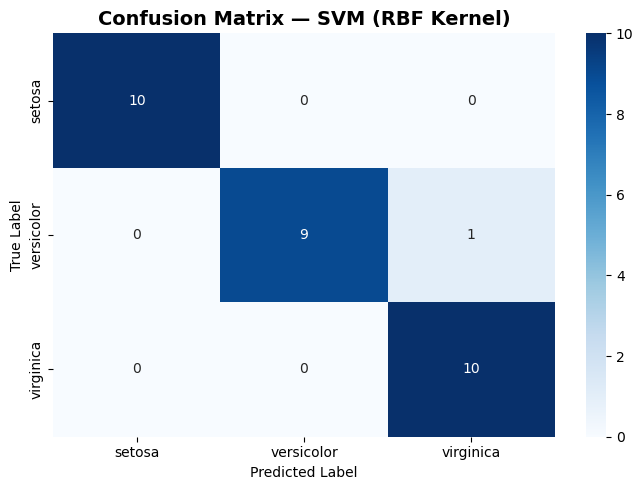

 Plot saved: iris_confusion_matrix.png


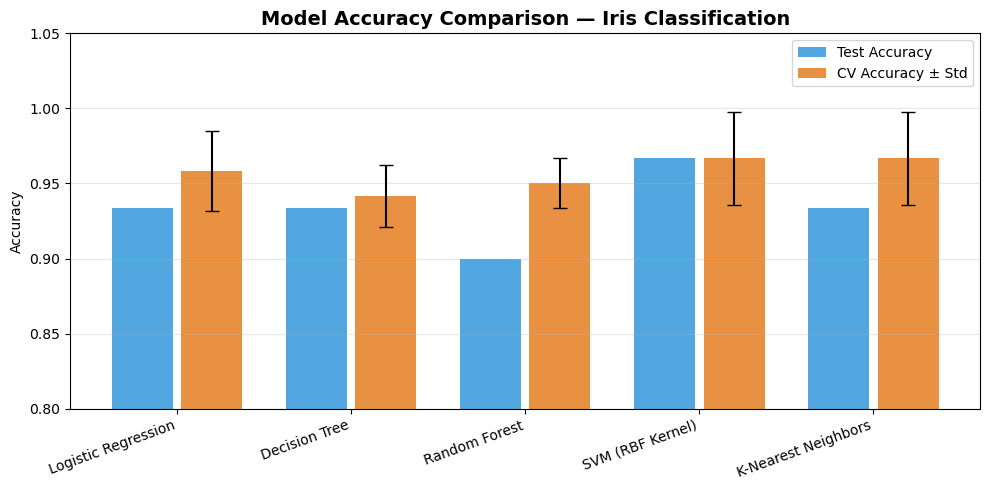

 Plot saved: iris_model_comparison.png


In [9]:
# 5. BEST MODEL — DETAILED EVALUATION

best_name = max(results, key=lambda k: results[k]['cv_mean'])
best_model = models[best_name]
best_model.fit(X_train_sc, y_train)
y_pred_best = best_model.predict(X_test_sc)

print(f"\nBEST MODEL: {best_name}")
print(f"\nTest Accuracy: {accuracy_score(y_test, y_pred_best)*100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_best,
      target_names=iris.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title(f"Confusion Matrix — {best_name}", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("iris_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved: iris_confusion_matrix.png")

# Model Accuracy Bar Chart
fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
accs  = [results[n]['test_accuracy'] for n in names]
cv_means = [results[n]['cv_mean'] for n in names]
cv_stds  = [results[n]['cv_std'] for n in names]

x = np.arange(len(names))
bars = ax.bar(x - 0.2, accs, 0.35, label='Test Accuracy', color='#3498db', alpha=0.85)
ax.bar(x + 0.2, cv_means, 0.35, yerr=cv_stds, label='CV Accuracy ± Std',
       color='#e67e22', alpha=0.85, capsize=5)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0.8, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Model Accuracy Comparison — Iris Classification", fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("iris_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(" Plot saved: iris_model_comparison.png")
